# Exploratory Data Analysis (EDA)

## Business Problem

Burger sales are believed to be influenced by weather conditions such as temperature, humidity, wind, visibility, and pressure.

The objective of this notebook is to understand the data through visualization and statistical analysis before developing forecasting models.

---

## Objectives

- Understand the sales distribution.
- Analyze weather variables.
- Compare sales across regions.
- Identify trends and anomalies.
- Investigate relationships between weather and sales.
- Generate insights that will improve predictive modeling.

In [63]:
# ==========================================================
# Exploratory Data Analysis
# ==========================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Makes plots appear inside Jupyter Notebook
%matplotlib inline

# Improve notebook appearance
plt.style.use("ggplot")

# Display options
pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

In [64]:
# ==========================================================
# Load Clean Dataset
# ==========================================================

df = pd.read_csv("../data/burger_data_clean.csv")

# Convert Date back to datetime
df["Date"] = pd.to_datetime(df["Date"])

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,Date,Region,Temperature,Humidity,Wind,Visibility,Pressure,Sales
0,2014-01-01,Reg1,17.471199,0.753878,6.755839,13.807525,1014.437661,1539.45
1,2014-01-01,Reg1,17.471199,0.753878,6.755839,13.807525,1014.437661,1539.45
2,2014-01-02,Reg1,15.486660,0.957388,0.503180,5.949232,1012.246198,2205.38
3,2014-01-03,Reg1,7.495190,0.816925,5.716267,9.644521,1024.722764,405.83
4,2014-01-04,Reg1,8.621881,0.952650,5.801921,15.760321,1016.718063,3200.50


In [65]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names")

for column in df.columns:
    print(f"• {column}")

DATASET OVERVIEW
Rows    : 24452
Columns : 8

Column Names
• Date
• Region
• Temperature
• Humidity
• Wind
• Visibility
• Pressure
• Sales


Instead of showing variables across the top, .T (transpose) puts each feature on its own row, making the table much easier to read.

In [66]:
# ==========================================================
# Summary Statistics
# ==========================================================

summary = df.describe().T

summary

,count,mean,min,25%,50%,75%,max,std
Date,24452,2017-05-09 08:07:19.326026496,2014-01-01 00:00:00,2015-09-05 00:00:00,2017-05-10 00:00:00,2019-01-12 00:00:00,2020-09-15 00:00:00,NaN
Temperature,24452.0,13.077983,-7.170076,4.339098,13.964321,21.806907,33.538482,9.570377
Humidity,24452.0,0.718637,0.0,0.547674,0.73411,0.902635,0.999396,0.199502
Wind,24452.0,10.697089,0.0,5.420347,9.413059,14.989989,36.206303,6.744509
Visibility,24452.0,9.995832,0.0,6.852248,10.556258,13.603445,16.093742,4.180311
Pressure,24452.0,1006.652858,86.812146,1012.553397,1016.485676,1020.80826,1032.238678,81.591888
Sales,24452.0,1873.49637,0.16,846.5425,2026.07,2894.3925,3564.54,1085.70014


In [67]:
# ==========================================================
# Missing Values
# ==========================================================

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing

,Missing Values,Percentage
Date,0,0.0
Region,0,0.0
Temperature,0,0.0
Humidity,0,0.0
Wind,0,0.0
Visibility,0,0.0
Pressure,0,0.0
Sales,0,0.0


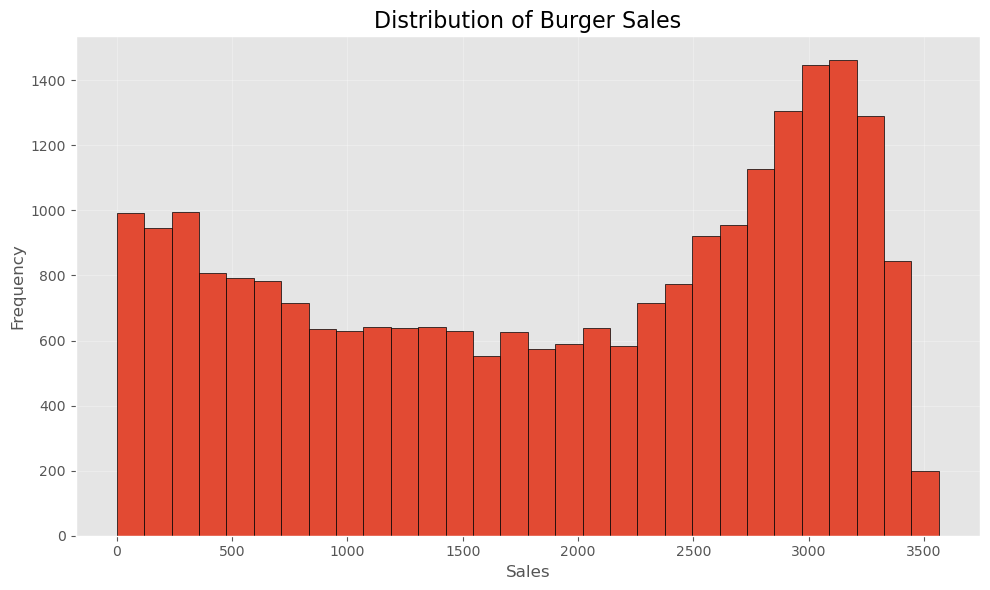

In [68]:
# ==========================================================
# Distribution of Burger Sales
# ==========================================================

from pathlib import Path

# Ensure output directory exists
Path("../outputs/figures").mkdir(parents=True, exist_ok=True)

# Create a figure
plt.figure(figsize=(10, 6))

# Plot histogram
plt.hist(
    df[column],
    bins=30,
    edgecolor="black"
)

# Add titles
plt.title("Distribution of Burger Sales", fontsize=16)

plt.xlabel("Sales", fontsize=12)

plt.ylabel("Frequency", fontsize=12)

# Add grid
plt.grid(alpha=0.3)

# Tight layout
plt.tight_layout()

# Save the figure
plt.savefig("../outputs/figures/sales_distribution.png", dpi=300)

# Display
plt.show()

Before building predictive models, I explored the target variable to understand its distribution, identify skewness or outliers, and determine whether any preprocessing or transformation might be needed.

## Average Burger Sales by Region

This analysis compares the average burger sales across the ten regions.

Understanding regional performance helps identify high-performing markets and reveals whether regional differences should be considered when building forecasting models.

In [69]:
# ==========================================================
# Average Sales by Region
# ==========================================================

# Calculate average sales for each region
region_sales = (
    df.groupby("Region")["Sales"]
      .mean()
      .sort_values(ascending=False)
)

# Display the results
print(region_sales)

Region
Reg10    1952.819459
Reg4     1897.194346
Reg2     1884.185227
Reg8     1882.815280
Reg5     1881.845127
Reg6     1868.169277
Reg3     1865.189211
Reg9     1845.748500
Reg1     1831.275387
Reg7     1825.881917
Name: Sales, dtype: float64


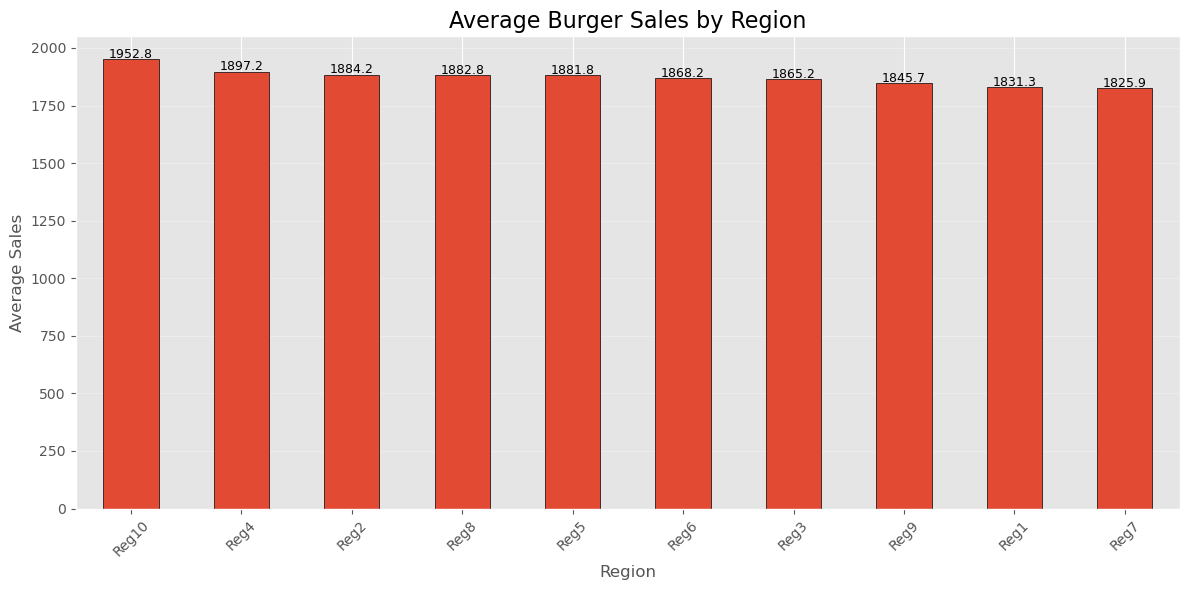

In [70]:
# ==========================================================
# Average Sales by Region (Enhanced)
# ==========================================================

plt.figure(figsize=(12,6))

ax = region_sales.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Burger Sales by Region", fontsize=16)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Average Sales", fontsize=12)

# Add value labels on each bar
for i, value in enumerate(region_sales.values):
    ax.text(i, value + 5, f"{value:.1f}", ha="center", fontsize=9)

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig("../outputs/figures/average_sales_by_region.png", dpi=300)

plt.show()

### Observation

- Region 10 recorded the highest average burger sales (1952.82).
- Region 7 recorded the lowest average burger sales (1825.88).
- The variation in average sales across regions is relatively small (approximately 127 units).
- This indicates that while regional differences exist, they are not substantial enough to explain sales on their own.
- The Region feature will still be retained for modeling because regional weather conditions and local demand patterns may influence forecasts.

## Why analyze regions
Regional performance may differ due to customer demographics, local demand, or climate. By analyzing average sales by region, I could determine whether region-specific behavior should be captured by the forecasting model

# Correlation Analysis

Correlation analysis helps identify linear relationships between weather variables and burger sales.

Correlation values range from:

- **+1** → Perfect positive relationship
- **0** → No linear relationship
- **-1** → Perfect negative relationship

This provides an initial indication of which features may be useful predictors.

In [71]:
# ==========================================================
# Correlation Matrix
# ==========================================================

# Select only numeric columns
numeric_df = df.select_dtypes(include=["number"])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Display the matrix
correlation_matrix

,Temperature,Humidity,Wind,Visibility,Pressure,Sales
Temperature,1.000000,-0.646802,0.195559,-0.114627,0.063805,-0.170997
Humidity,-0.646802,1.000000,-0.628398,-0.121761,-0.164203,0.505933
Wind,0.195559,-0.628398,1.000000,0.413856,0.128249,-0.154255
Visibility,-0.114627,-0.121761,0.413856,1.000000,0.281621,0.140904
Pressure,0.063805,-0.164203,0.128249,0.281621,1.000000,-0.126423
Sales,-0.170997,0.505933,-0.154255,0.140904,-0.126423,1.000000


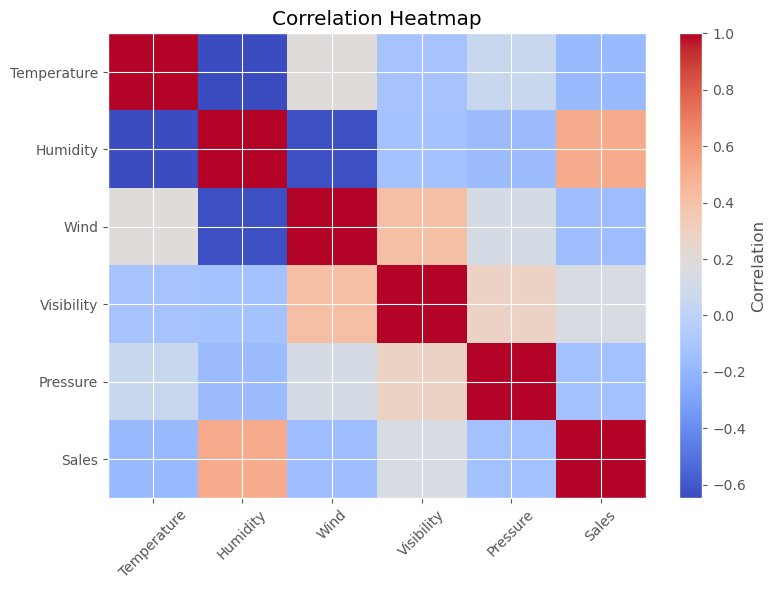

In [72]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("../outputs/figures/correlation_heatmap.png", dpi=300)

plt.show()

## Why a correlation matrix?

I used the correlation matrix as an initial exploratory tool to identify potential linear relationships between weather variables and burger sales. Although LSTM models can learn nonlinear patterns, understanding feature relationships helps guide feature engineering and interpretability.

## Key Findings from the Correlation Analysis

- Humidity has the strongest positive correlation with burger sales (**0.506**), suggesting it may be an important predictor.
- Temperature, wind, visibility, and pressure show relatively weak linear relationships with sales.
- Temperature and humidity exhibit a moderately strong negative correlation (-0.647), indicating that warmer days tend to have lower humidity in this dataset.
- Correlation analysis only captures linear relationships. The LSTM model developed later in the project will be capable of learning more complex, nonlinear patterns.

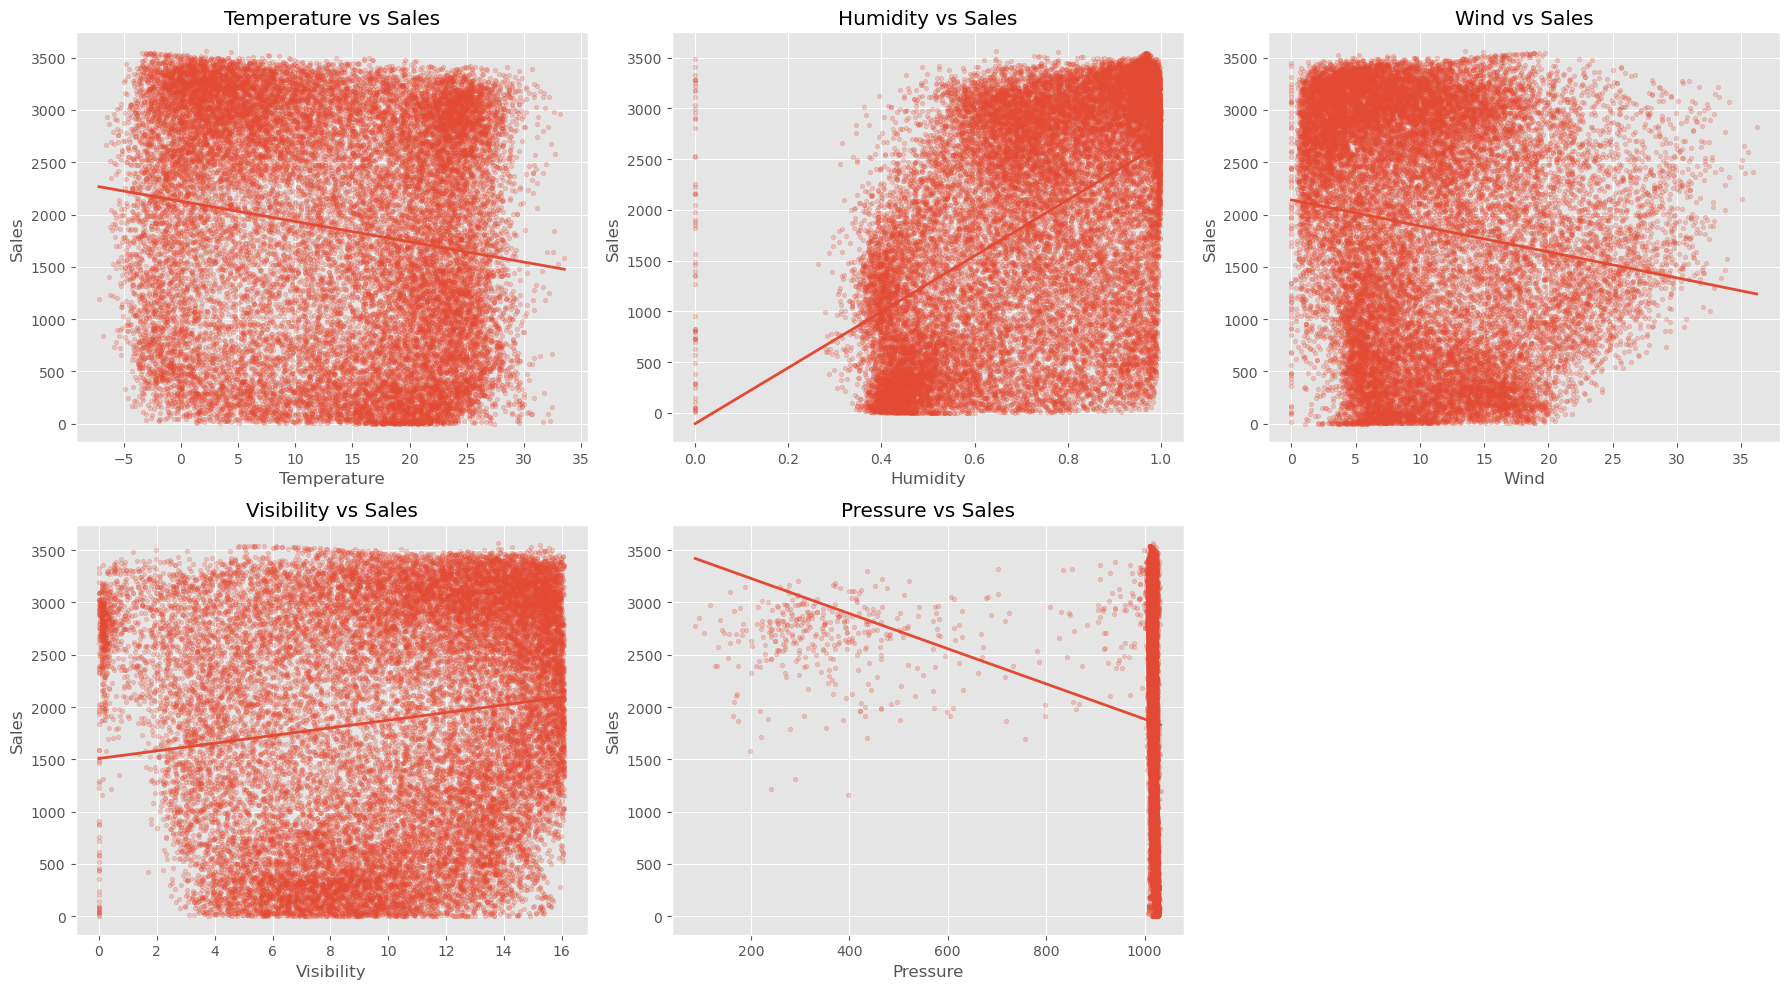

In [73]:
# ==========================================================
# Weather Variables vs Sales (Enhanced)
# ==========================================================

weather_features = [
    "Temperature",
    "Humidity",
    "Wind",
    "Visibility",
    "Pressure"
]

plt.figure(figsize=(18,10))

for i, feature in enumerate(weather_features):

    plt.subplot(2,3,i+1)

    x = df[feature]
    y = df["Sales"]

    plt.scatter(x, y, alpha=0.25, s=10)

    # Add linear trend line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)

    plt.plot(
        np.sort(x),
        p(np.sort(x)),
        linewidth=2
    )

    plt.title(f"{feature} vs Sales")

    plt.xlabel(feature)

    plt.ylabel("Sales")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/weather_vs_sales.png",
    dpi=300
)

plt.show()

In [74]:
# ==========================================================
# Check Pressure Values
# ==========================================================

print("Minimum Pressure:", df["Pressure"].min())

print("\nNumber of pressure values equal to 0:")
print((df["Pressure"] == 0).sum())

print("\nTop 10 most frequent pressure values:")
print(df["Pressure"].value_counts().head(10))

Minimum Pressure: 86.81214641

Number of pressure values equal to 0:
0

Top 10 most frequent pressure values:
Pressure
1016.485676    44
1017.570087     4
1014.910045     3
1017.956090     3
1014.915221     3
1011.409329     3
1017.210779     3
1021.394686     3
1011.138460     3
1019.070688     3
Name: count, dtype: int64


## Observations from Scatter Plots

- Humidity exhibits the clearest positive relationship with burger sales.
- Temperature and wind show weak negative trends.
- Visibility has only a slight positive relationship with sales.
- Pressure requires further investigation because some observations contain unrealistic values (0 hPa).
- The relationships are not perfectly linear, reinforcing the need for models such as LightGBM and LSTM that can capture more complex patterns.

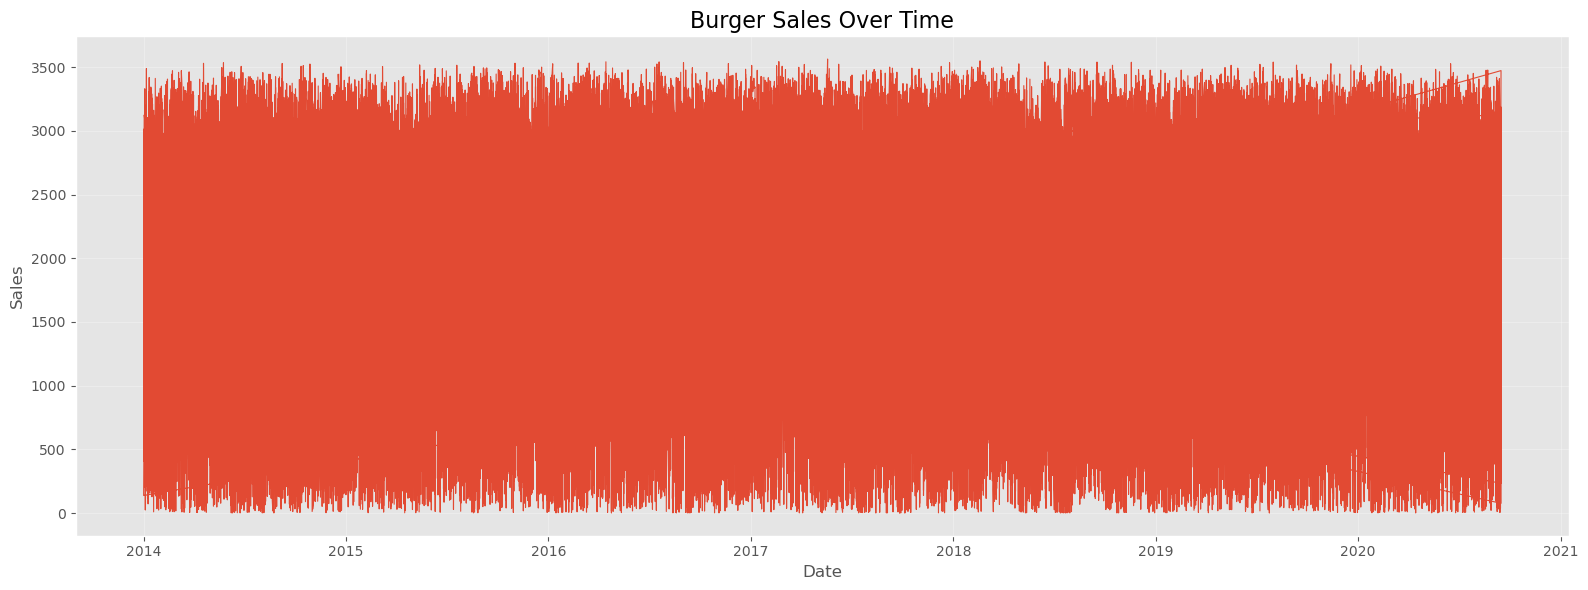

In [75]:
# ==========================================================
# Sales Over Time
# ==========================================================

plt.figure(figsize=(16,6))

plt.plot(
    df["Date"],
    df["Sales"],
    linewidth=0.8
)

plt.title("Burger Sales Over Time", fontsize=16)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/sales_over_time.png",
    dpi=300
)

plt.show()

In [76]:
# ==========================================================
# Replace Invalid Pressure Values
# ==========================================================

# Count invalid values before replacement
invalid_pressure = (df["Pressure"] == 0).sum()

print(f"Invalid pressure values before replacement: {invalid_pressure}")

# Calculate the median using only valid pressure values
median_pressure = df.loc[df["Pressure"] > 0, "Pressure"].median()

# Replace zeros with the median
df.loc[df["Pressure"] == 0, "Pressure"] = median_pressure

# Verify
print(f"Invalid pressure values after replacement: {(df['Pressure'] == 0).sum()}")

print(f"Median pressure used: {median_pressure:.2f}")

Invalid pressure values before replacement: 0
Invalid pressure values after replacement: 0
Median pressure used: 1016.49


In [77]:
# Save updated dataset
df.to_csv("../data/burger_data_clean.csv", index=False)

print("Updated cleaned dataset saved successfully.")

Updated cleaned dataset saved successfully.


## Monthly Average Burger Sales

Daily sales fluctuate substantially, making it difficult to identify long-term trends.

Aggregating sales by month helps reveal seasonal patterns and overall business performance over time.

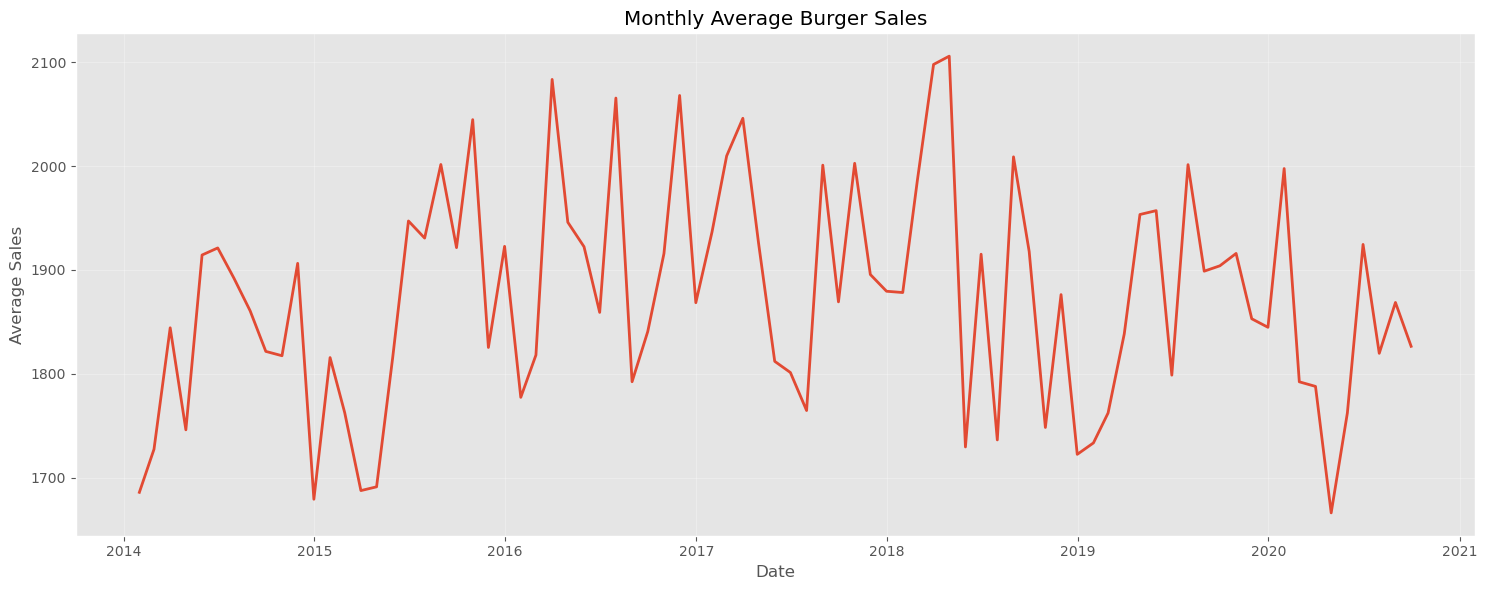

In [78]:
# ==========================================================
# Monthly Average Sales
# ==========================================================

monthly_sales = (
    df.set_index("Date")
      .resample("M")["Sales"]
      .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=2
)

plt.title("Monthly Average Burger Sales")

plt.xlabel("Date")

plt.ylabel("Average Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/monthly_average_sales.png",
    dpi=300
)

plt.show()

# Conclusions

The exploratory data analysis provided several important insights:

- The dataset contains over 24,000 observations with weather and sales information spanning multiple years.
- Duplicate records and invalid pressure values were identified and corrected.
- Burger sales exhibit considerable variability, making forecasting a meaningful task.
- Humidity showed the strongest positive linear relationship with burger sales.
- Temperature, wind, visibility, and pressure displayed relatively weak linear relationships with sales.
- Regional differences in average sales were present but modest.
- Time-series visualization showed stable sales levels over the years with substantial daily fluctuations.
- These findings support the use of advanced forecasting models, such as LightGBM and LSTM, capable of learning complex relationships and temporal dependencies.